# Ayudantía 13: Tópicos Avanzados 1

## Ayudantes 👾

Y sus recomendaciones semanales 🎵

- S1: Josefa Buch 
  - [The Beatles - Sgt. Pepper's Lonely Hearts Club Band ](https://open.spotify.com/intl-es/track/7BgUsF8L4cMhtBlPzo8den?nd=1&dlsi=5ac10f6465664111)
- S2: Bastián Pérez
  - [Iron Maiden - the Trooper](https://www.youtube.com/watch?v=X4bgXH3sJ2Q)
- S3: Daniel Villaseñor
  - [Patawawa - All The Time](https://www.youtube.com/watch?v=sDb9nv79fys&list=RDsDb9nv79fys&start_radio=1)
- S4: André Angulo
  - [Wisin & Yandel - Calle Callejero](https://www.youtube.com/watch?v=Qe4EQFASBq0&list=RDQe4EQFASBq0&start_radio=1)
- S5: Clemente Campos
  - [Wednesday - Elderberry Wine](https://open.spotify.com/intl-es/track/00lSB9CSyOcsxKVtbPbniL?nd=1&dlsi=7c90bfa09bf34e78)

Y con aparición especial de:
  - Pablo Araneda (Profe S2)
    - [KAITO - When I Get Home My Wife Always Pretends to be Dead](https://www.youtube.com/watch?v=RGlnVDCC4NI)

## Contenidos 📖

- Expresiones regulares (RegEx)
- Grafos y representación
- Búsqueda en grafos
- Numpy
- Pandas

# Parte 1: DCCMail

En DCCMail, la plataforma interna de correos del departamento, se guardan registros de mensajes en un archivo de texto. El problema es que el archivo viene con líneas mal formateadas, espacios extra y algunos correos inválidos. Tu misión será procesar esos registros, construir una red de comunicación y responder consultas sobre quién puede llegar a quién.

La idea es usar dos herramientas distintas:

- `regex` para validar y extraer datos desde texto crudo.
- Grafos y recorridos para modelar y explorar la red de correos.


## 1.1. Validación y extracción con `regex`

Cada línea del archivo representa un correo con este formato:

```text
YYYY-MM-DD HH:MM | remitente -> destinatario | asunto: texto del asunto
```

Por ejemplo:

```text
2026-06-01 14:32 | ana@uc.cl -> bob@gmail.com | asunto: Ayuda con tarea
```

Las líneas inválidas pueden tener alguno de estos problemas:

- Fecha u hora mal escritas.
- Correo mal formado.
- Falta alguno de los separadores `|` o `->`.
- Asunto vacío.
- Espacios extra o texto sucio.

Debes implementar una función que reciba una línea y decida si representa un correo válido. Si la línea es válida, debe devolver un objeto con los campos:

- `fecha`
- `hora`
- `remitente`
- `destinatario`
- `asunto`

Consideraciones:

- Usa `re.fullmatch` si quieres validar toda la línea completa.
- Puedes usar grupos de captura o grupos nombrados para extraer cada campo.
- Si una línea no cumple el formato, debes ignorarla.
- El archivo `data/correos.txt` puede servirte de ejemplo.

In [1]:
import re
from pathlib import Path
from collections import deque, namedtuple


Correo = namedtuple(
    "Correo",
    ["fecha", "hora", "remitente", "destinatario", "asunto"],
)


In [2]:
def extraer_correo(linea: str) -> Correo:
    """
    Recibe una linea y devuelve un Correo si el formato es valido.
    Si no lo es, devuelve None.
    """
    patron = (
        r"\s*(?P<fecha>\d{4}-\d{2}-\d{2})\s+"
        r"(?P<hora>([01]\d|2[0-3]):[0-5]\d)\s*"
        r"\|\s*"
        r"(?P<remitente>[\w.+-]+@[\w-]+(\.[\w-]+)+)\s*"
        r"->\s*"
        r"(?P<destinatario>[\w.+-]+@[\w-]+(\.[\w-]+)+)\s*"
        r"\|\s*asunto:\s*(?P<asunto>.+)\s*"
    )
    match = re.fullmatch(patron, linea)

    if match is None:
        return None

    datos = match.groupdict()
    asunto = datos["asunto"].strip()

    if not asunto:
        return None

    return Correo(
        datos["fecha"],
        datos["hora"],
        datos["remitente"].strip(),
        datos["destinatario"].strip(),
        asunto,
    )


def leer_correos(ruta: Path) -> list[Correo]:
    """
    Lee un archivo y genera solo los correos validos.
    """
    correos = []

    for linea in ruta.read_text(encoding="utf-8").splitlines():
        correo = extraer_correo(linea)
        if correo is not None:
            correos.append(correo)

    return correos


In [3]:
PATH = Path('data', 'correos.txt')
correos = leer_correos(PATH)

for correo in correos:
    print(correo)

Correo(fecha='2026-06-01', hora='14:32', remitente='ana@uc.cl', destinatario='bob@gmail.com', asunto='Ayuda con tarea')
Correo(fecha='2026-06-01', hora='14:35', remitente='bob@gmail.com', destinatario='carla@uc.cl', asunto='Re: Ayuda con tarea')
Correo(fecha='2026-06-01', hora='14:40', remitente='carla@uc.cl', destinatario='diego@outlook.com', asunto='Re: Re: Ayuda con tarea')
Correo(fecha='2026-06-01', hora='15:00', remitente='ana@uc.cl', destinatario='diego@outlook.com', asunto='Consulta urgente')
Correo(fecha='2026-06-01', hora='15:25', remitente='laura@uc.cl', destinatario='marta@uc.cl', asunto='Reunion de equipo')


## 1.2. Construcción del grafo

Con todos los correos válidos, debes construir un grafo dirigido donde cada nodo es un correo electrónico y existe una arista `A -> B` si `A` le envió al menos un correo a `B`.

Requisitos del grafo:

- Cada correo debe existir como nodo, aunque no tenga salidas.
- Si se repite la misma comunicación, no debes duplicar la arista.
- Una representación conveniente es `dict[str, set[str]]`.

A continuación, un ejemplo:

```python
{
    "ana@uc.cl": {"bob@gmail.com", "diego@outlook.com"},
    "bob@gmail.com": {"carla@uc.cl"},
    "carla@uc.cl": {"diego@outlook.com"},
    "diego@outlook.com": set()
}
```

Sugerencia: si encuentras un remitente o destinatario nuevo, agrégalo al grafo antes de conectar la arista.

In [4]:
class Nodo:
    """
    Nodo simple para representar un correo electronico.
    """

    def __init__(self, valor: Correo):
        self.valor = valor
        self.vecinos: list[Nodo] = []

    def agregar_vecino(self, nodo):
        self.vecinos.append(nodo)

    def __repr__(self):
        texto = f"[{self.valor}]"
        if self.vecinos:
            vecinos = [f"[{vecino.valor}]" for vecino in self.vecinos]
            texto += " -> " + ", ".join(vecinos)
        return texto


def construir_grafo(correos: list[Correo]) -> dict[str, set[str]]:
    """
    Construye un grafo dirigido a partir de una secuencia de correos.
    """
    grafo = dict()

    for correo in correos:
        if correo.remitente not in grafo:
            grafo[correo.remitente] = set()
        if correo.destinatario not in grafo:
            grafo[correo.destinatario] = set()

        grafo[correo.remitente].add(correo.destinatario)

    return grafo


In [5]:
correos_demo = [
    Correo("2026-06-01", "14:32", "ana@uc.cl", "bob@gmail.com", "Ayuda con tarea"),
    Correo("2026-06-01", "14:35", "bob@gmail.com", "carla@uc.cl", "Re: Ayuda con tarea"),
    Correo("2026-06-01", "14:40", "carla@uc.cl", "diego@outlook.com", "Re: Re: Ayuda con tarea"),
    Correo("2026-06-01", "15:00", "ana@uc.cl", "diego@outlook.com", "Consulta urgente"),
]

grafo = construir_grafo(correos_demo)

for nodo, vecinos in grafo.items():
    print(f"{nodo} -> {vecinos}")

ana@uc.cl -> {'diego@outlook.com', 'bob@gmail.com'}
bob@gmail.com -> {'carla@uc.cl'}
carla@uc.cl -> {'diego@outlook.com'}
diego@outlook.com -> set()


## 1.3. Camino más corto en la red

En esta parte debes implementar una función que encuentre el camino más corto entre dos correos dentro de la red.

La función que debes completar es `camino_mas_corto(grafo, origen, destino) -> list[str] | None`

La red se entrega como un grafo dirigido representado con listas de adyacencia, es decir, como un `dict[str, set[str]]`.

Tu objetivo es retornar una lista con el camino más corto desde `origen` hasta `destino`, incluyendo ambos extremos. Si no existe un camino entre ellos, debes retornar `None`.


Pistas: 

- Guarda el predecesor de cada nodo para reconstruir el camino al final.
- Si el `origen` o el `destino` no existen en el grafo, retorna `None`.
- Si `origen == destino`, el camino es una lista con ese único correo.

Recuerda que hemos visto dos manera de recorrer grafos. ¿Cuál crees que es la más conveniente acá?.

In [6]:
def camino_mas_corto(grafo: dict[str, set[str]],
                     origen: str,
                     destino: str) -> list[str] | None:
    """Retorna una lista con el camino mas corto entre dos nodos.

    Si no existe camino, retorna None.
    """
    if origen not in grafo or destino not in grafo:
        return None

    if origen == destino:
        return [origen]

    visitados = set()
    predecesores = dict()
    queue = deque([origen])

    while len(queue) > 0:
        vertice = queue.popleft()

        if vertice in visitados:
            continue

        visitados.add(vertice)

        for vecino in grafo[vertice]:
            if vecino in visitados:
                continue

            if vecino not in predecesores:
                predecesores[vecino] = vertice

            if vecino == destino:
                camino = [destino]
                while camino[-1] != origen:
                    camino.append(predecesores[camino[-1]])
                camino.reverse()
                return camino

            queue.append(vecino)

    return None


In [7]:
correos_demo = [
    Correo("2026-06-01", "14:32", "ana@uc.cl", "bob@gmail.com", "Ayuda con tarea"),
    Correo("2026-06-01", "14:35", "bob@gmail.com", "carla@uc.cl", "Re: Ayuda con tarea"),
    Correo("2026-06-01", "14:40", "carla@uc.cl", "diego@outlook.com", "Re: Re: Ayuda con tarea"),
    Correo("2026-06-01", "15:00", "ana@uc.cl", "diego@outlook.com", "Consulta urgente"),
]

grafo_demo = construir_grafo(correos_demo)

print(camino_mas_corto(grafo_demo, "ana@uc.cl", "diego@outlook.com"))
print(camino_mas_corto(grafo_demo, "ana@uc.cl", "carla@uc.cl"))
print(camino_mas_corto(grafo_demo, "carla@uc.cl", "ana@uc.cl"))

['ana@uc.cl', 'diego@outlook.com']
['ana@uc.cl', 'bob@gmail.com', 'carla@uc.cl']
None


# Parte 2:
<pre style="font-family: 'Courier New', Courier, monospace; line-height: 1.2; font-size: 13px; color: rgb(216, 218, 216);">
 ██████╗  ██████╗ ██████╗██╗  ██╗██╗███╗   ██╗███████╗
 ██╔══██╗██╔════╝██╔════╝██║  ██║██║████╗  ██║██╔════╝
 ██║  ██║██║     ██║     ███████║██║██╔██╗ ██║█████╗  
 ██║  ██║██║     ██║     ██╔══██║██║██║╚██╗██║██╔══╝  
 ██████╔╝╚██████╗╚██████╗██║  ██║██║██║ ╚████║███████╗
 ╚═════╝  ╚═════╝ ╚═════╝╚═╝  ╚═╝╚═╝╚═╝  ╚═══╝╚══════╝

 ██╗     ███████╗ █████╗ ██████╗ ███╗   ██╗██╗███╗   ██╗ ██████╗ 
 ██║     ██╔════╝██╔══██╗██╔══██╗████╗  ██║██║████╗  ██║██╔════╝ 
 ██║     █████╗  ███████║██████╔╝██╔██╗ ██║██║██╔██╗ ██║██║  ███╗
 ██║     ██╔══╝  ██╔══██║██╔══██╗██║╚██╗██║██║██║╚██╗██║██║   ██║
 ███████╗███████╗██║  ██║██║  ██║██║ ╚████║██║██║ ╚████║╚██████╔╝
</pre><img src="https://media1.giphy.com/media/j0HjChGV0J44KrrlGv/giphy.gif" width="160" style="border-radius: 8px;" />
</div><img src="https://media0.giphy.com/media/rQNY1TP5TUqPAKgx2A/giphy.gif" width="180" style="border-radius: 8px;" />
</div>

<span style="color: #39FF14;">$ system boot complete — IIC2233 Terminal v2026.1</span>

⚡ Felicitaciones, alumno.

Has completado el curso de Programación Avanzada.
Dominaste OOP, estructuras de datos, concurrencia, interfaces y más. Pero el mundo real tiene hambre de algo más...

Es hora de adentrarte en el reino de otro ramo. Hoy comienza tu viaje por el mundo de la inteligencia artificial, específicamente del <span style="color: #39FF14;">$ Machine Learning</span>. Los algoritmos ya existen. Los modelos también. Pero ninguno puede aprender solo.

En algún lugar del laboratorio del DCC, un modelo espera ser entrenado.
Miles de filas de datos llegan cada segundo: registros incompletos, patrones ocultos, variables que nadie ha explorado todavía.
Tu misión será convertir ese caos en conocimiento.Para lograrlo, deberás asumir el rol de científico de datos.
No bastará con escribir código: tendrás que entender los datos, limpiarlos, transformarlos y descubrir qué historia esconden. Tus herramientas serán simples, pero poderosas:

- <span style="color: #39FF14;">$ pandas</span> → para navegar, limpiar y estructurar el flujo de información.

- <span style="color: #39FF14;">$ numpy</span> → para operar sobre grandes volúmenes de datos y preparar el terreno donde aprenderá el modelo.

Cada análisis que realices acercará al sistema a producir mejores predicciones.
Cada decisión incorrecta puede introducir sesgos, ruido… o hacer que el modelo falle.

Pero antes de partir…

El DCC te pone a prueba una última vez.

Completa los ejercicios de hoy y demuestra que estás listo para el siguiente nivel.

<span style="color: #39FF14;">$ Bienvenido a la Ciencia de Datos.</span>


## CASO: Predecir el próximo hit musical 🎵

Es 2026. Spotify, Apple Music y las grandes discográficas se están peleando por el mismo recurso escaso: **saber qué canción será viral antes de que salga**.

Una startup de Santiago llamada **DCCHits** ha recopilado datos de **15.000 canciones** publicadas entre 2010 y 2024, con características sonoras medidas automáticamente (energía, tempo, bailabilidad), datos comerciales (sello, plataforma, colaboraciones) y métricas de éxito.

Te han contratado como analista de datos. Tu misión tiene dos etapas:

**Etapa 1 — Entender los datos** *(esta ayudantía)*: explorar el dataset, detectar problemas, encontrar patrones y dejar los datos listos para modelar.

**Etapa 2 — Predecir** *(Tarea para otro curso)* 👀

La variable objetivo es `streams_categoria`, es decir la variable que indica la popularidad de la canción y la que se busca predecir::

| Valor | Significado |
|-------|-------------|
| `0` | Baja popularidad |
| `1` | Popularidad media |
| `2` | Alta popularidad |
| `3` | Viral 🔥 |



> *"Antes de predecir, hay que entender. Un modelo entrenado sobre datos sucios es peor que no tener modelo."* — DCCHits, Manual interno

---

## importaciones


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os import path

## Ejercicio 1 - Análisis exploratorio de datos con pandas 🐼

### 1.1 — Carga y estructura del dataset

Carga el archivo `dcchine_musica.csv` en un DataFrame. Luego usa `.info()` y `.head()` para responder:

- ¿Cuántas filas y columnas tiene el dataset?
- ¿Hay columnas que deberían ser numéricas pero aparecen como `object`? ¿Cuáles y por qué crees que ocurre?
- ¿Qué columnas podrían no ser útiles para predecir `streams_categoria`? Menciona al menos dos y justifica.
- ¿Cuales son las primeras 5 filas del dataset? 

In [7]:
data = path.join("data", "dcchine_musica.csv")
df = pd.read_csv(data)

print(f"Filas: {len(df)}, Columnas: {len(df.columns)}")
print()
df.info()

Filas: 15000, Columnas: 19

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   genero                   15000 non-null  object 
 1   plataforma               15000 non-null  object 
 2   idioma                   15000 non-null  object 
 3   dia_lanzamiento          15000 non-null  object 
 4   anno_lanzamiento         15000 non-null  int64  
 5   duracion_seg             15000 non-null  int64  
 6   tempo_bpm                15000 non-null  int64  
 7   energia                  15000 non-null  float64
 8   valencia                 15000 non-null  float64
 9   bailabilidad             15000 non-null  float64
 10  instrumentalidad         15000 non-null  object 
 11  loudness_db              15000 non-null  object 
 12  popularidad_artista      15000 non-null  int64  
 13  num_colaboraciones       15000 non-null  int64  

El dataset tiene **15.000 filas y 19 columnas**. Las columnas `loudness_db`, `instrumentalidad`, aparecen como `object` a pesar de ser numéricas: esto ocurre porque contienen valores nulos (`NaN`) mezclados con números al momento de la carga, lo que fuerza a pandas a inferir el tipo como objeto.

En cuanto a columnas poco útiles para predecir: `dia_lanzamiento` (el día de la semana tiene baja influencia causal en el éxito) y `anno_lanzamiento` (el año de lanzamiento puede introducir sesgo temporal sin aportar información musical relevante).

In [6]:
df.head(5)

,genero,plataforma,idioma,dia_lanzamiento,anno_lanzamiento,duracion_seg,tempo_bpm,energia,valencia,bailabilidad,instrumentalidad,loudness_db,popularidad_artista,num_colaboraciones,semanas_en_charts,reproducciones_millones,gastos_produccion_usd,sello_discografico,streams_categoria
0,Hip-Hop,Apple Music,Ingles,Martes,2012,257,129,0.477,0.623,0.802,0.041,-0.8,82,3,31,1.27,210327.0,Sony,1
1,Cumbia,YouTube Music,Ingles,Martes,2014,162,145,0.336,0.177,0.913,0.415,-16.6,32,0,30,4.37,407717.0,Warner,0
2,Metal,Apple Music,Coreano,Domingo,2016,176,154,0.558,0.640,0.574,0.235,-4.9,54,1,7,4.81,173873.0,Sony,0
3,Reggaeton,Spotify,Espanol,Jueves,2010,235,132,0.610,0.623,0.473,0.043,-5.4,67,0,26,21.76,208898.0,Universal,3
4,Pop,Spotify,Ingles,Sabado,2023,137,143,0.809,0.345,0.325,0.303,-1.4,33,0,17,0.99,332421.0,Universal,1


### 1.2 — Distribución de la variable objetivo

Antes de cualquier análisis, hay que entender qué queremos predecir.

- Usa `.value_counts()` para ver cuántas canciones hay en cada categoría de `streams_categoria`.
- ¿El dataset está **balanceado** o **desbalanceado**? 
    - hint: ocupe `normalize=True` para obtener proporciones y luego .mul(100).round(1).astype(str) + " %" para mostrar porcentajes.
- Grafica la distribución con un gráfico de barras.
- `BONUS`: ¿Por qué el desbalance podría ser un problema al momento de entrenar un modelo?

In [ ]:
print(df["streams_categoria"].value_counts().sort_index())
print()
print("Proporciones:")
print(df["streams_categoria"].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + " %")

streams_categoria
0    5250
1    4500
2    3000
3    2250
Name: count, dtype: int64

Proporciones:
streams_categoria
0    35.0 %
1    30.0 %
2    20.0 %
3    15.0 %
Name: proportion, dtype: object


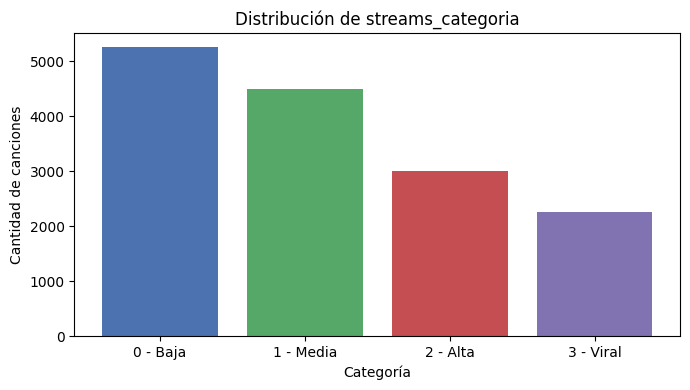

In [11]:
conteos = df["streams_categoria"].value_counts().sort_index()
etiquetas = ["0 - Baja", "1 - Media", "2 - Alta", "3 - Viral"]

plt.figure(figsize=(7, 4))
plt.bar(etiquetas, conteos.values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Distribución de streams_categoria")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de canciones")
plt.tight_layout()
plt.show()

El dataset está **desbalanceado**: la categoría `0 (Baja)` representa el 35% del total mientras que `3 (Viral)` solo el 15%. Esto es problemático para modelos de clasificación porque el modelo podría aprender a predecir siempre las clases mayoritarias y aun así tener buena precisión global, ignorando completamente los casos virales que son los más interesantes para DCCHits.

### 1.3 — Análisis de valores nulos

Calcula los valores nulos por columna. Muestra solo las columnas afectadas, con su cantidad y porcentaje.

- ¿Cuántos valores nulos tiene cada columna con faltantes?
- ¿Qué ocurre con loudness_db e instrumentalidad?  ¿Por qué no aparecen con sus valores nulos?

In [16]:
# Reemplazamos el string "<null>" por NaN real
df["loudness_db"] = pd.to_numeric(df["loudness_db"].replace("<null>", None), errors="coerce")
df["instrumentalidad"] = pd.to_numeric(df["instrumentalidad"].replace("<null>", None), errors="coerce")

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
porcentaje = (nulos / len(df) * 100).round(2)

resumen = pd.DataFrame({"nulos": nulos, "porcentaje (%)": porcentaje})
print(resumen)

                       nulos  porcentaje (%)
gastos_produccion_usd   1182            7.88
sello_discografico      1041            6.94
loudness_db              898            5.99
instrumentalidad         742            4.95


### 1.4 — Relación entre variables y la categoría objetivo

Esta es la pregunta más importante del análisis exploratorio: **¿qué variables se relacionan más con `streams_categoria`?**

Agrupa el DataFrame por `streams_categoria` y calcula el promedio de `energia`, `bailabilidad`, `popularidad_artista` y `semanas_en_charts` para cada grupo.

- ¿Alguna variable muestra una tendencia clara al aumentar la categoría?
- ¿Qué variables crees que serán más útiles para predecir si una canción es viral?
- Grafica los resultados con un gráfico de barras agrupadas.

In [17]:
features_interes = ["energia", "bailabilidad", "popularidad_artista", "semanas_en_charts"]

promedios = df.groupby("streams_categoria")[features_interes].mean()
print(promedios.round(3))

                   energia  bailabilidad  popularidad_artista  \
streams_categoria                                               
0                    0.547         0.554               34.092   
1                    0.608         0.609               51.303   
2                    0.638         0.633               62.534   
3                    0.670         0.652               67.975   

                   semanas_en_charts  
streams_categoria                     
0                             20.232  
1                             26.215  
2                             29.547  
3                             31.513  


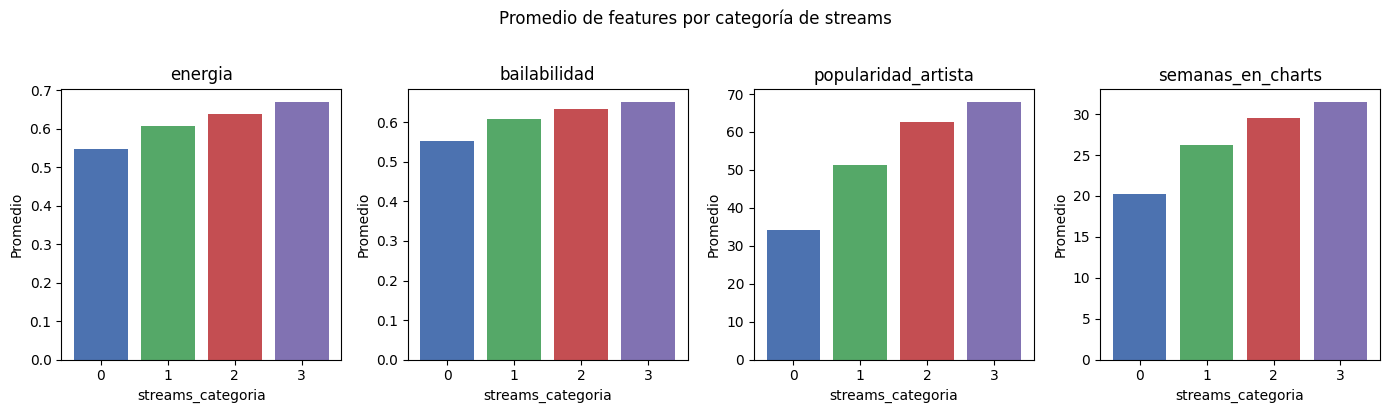

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, col in zip(axes, features_interes):
    ax.bar(["0","1","2","3"], promedios[col], color=colores)
    ax.set_title(col)
    ax.set_xlabel("streams_categoria")
    ax.set_ylabel("Promedio")

plt.suptitle("Promedio de features por categoría de streams", y=1.02)
plt.tight_layout()
plt.show()

### 1.5 — Filtrado de canciones

Filtra el DataFrame para quedarte solo con las canciones **virales** (`streams_categoria == 3`) que además fueron publicadas en **Spotify**.

> ¿Cuántas canciones cumplen ambas condiciones?

In [19]:
virales_spotify = df[(df["streams_categoria"] == 3) & (df["plataforma"] == "Spotify")]
print(f"Canciones virales en Spotify: {len(virales_spotify)}")
virales_spotify.head()

Canciones virales en Spotify: 1198


,genero,plataforma,idioma,dia_lanzamiento,anno_lanzamiento,duracion_seg,tempo_bpm,energia,valencia,bailabilidad,instrumentalidad,loudness_db,popularidad_artista,num_colaboraciones,semanas_en_charts,reproducciones_millones,gastos_produccion_usd,sello_discografico,streams_categoria
29,Pop,Spotify,Espanol,Jueves,2022,211,70,0.574,0.663,0.562,0.088,-2.3,38,1,3,28.52,159257.0,Sony,3
32,Pop,Spotify,Coreano,Domingo,2013,156,84,0.593,0.735,0.744,0.043,-1.5,16,1,7,20.89,293341.0,Independiente,3
42,Pop,Spotify,Ingles,Sabado,2014,251,143,0.550,0.843,0.713,0.118,-1.3,17,0,44,14.01,475275.0,Sony,3
68,Pop,Spotify,Ingles,Viernes,2014,244,112,0.883,0.625,0.497,0.575,-4.0,84,0,9,20.52,335360.0,Universal,3
71,Pop,Spotify,Espanol,Viernes,2011,206,120,0.940,0.594,0.686,0.268,-1.1,91,2,46,3.48,NaN,Sony,3


### 1.6 — Nueva columna: duración en minutos

Agrega una nueva columna llamada `duracion_min` que convierta `duracion_seg` a minutos (dividiendo por 60, redondeado a 2 decimales).

Luego muestra las 5 canciones más largas.

In [20]:
df["duracion_min"] = (df["duracion_seg"] / 60).round(2)

df.sort_values("duracion_min", ascending=False).head()[["genero", "plataforma", "duracion_seg", "duracion_min", "streams_categoria"]]

,genero,plataforma,duracion_seg,duracion_min,streams_categoria
14438,Electronica,Apple Music,357,5.95,0
13095,Cumbia,Apple Music,355,5.92,0
7993,Rock,Spotify,352,5.87,0
12748,Pop,Tidal,350,5.83,1
7657,Electronica,Spotify,348,5.80,2


Agregar columnas derivadas es una operación fundamental en análisis de datos. Aquí aplicamos una operación con escalar directamente sobre la columna, lo que pandas ejecuta de forma vectorizada (sin loops) gracias a su base en NumPy.

### `BONUS`: 1.7 — Análisis de variables categóricas

Usa `pd.crosstab` para cruzar `genero` con `streams_categoria`, **normalizado por fila** (es decir, que muestre proporciones dentro de cada género, no conteos absolutos).

- ¿Qué géneros tienen la mayor proporción de canciones virales (categoría 3)?
- ¿Hay algún género donde la categoría `0 (Baja)` sea dominante?
- Grafica la tabla como barras apiladas.


In [25]:
tabla = pd.crosstab(df["genero"], df["streams_categoria"], normalize="index").round(3)
tabla.columns = ["0-Baja", "1-Media", "2-Alta", "3-Viral"]
tabla = tabla.sort_values("3-Viral", ascending=False)
print(tabla)

             0-Baja  1-Media  2-Alta  3-Viral
genero                                       
Pop           0.273    0.310   0.224    0.192
Hip-Hop       0.276    0.289   0.251    0.185
Reggaeton     0.276    0.310   0.229    0.185
Metal         0.394    0.313   0.159    0.133
Jazz          0.410    0.301   0.166    0.123
Electronica   0.402    0.306   0.169    0.123
R&B           0.438    0.276   0.164    0.122
Clasica       0.405    0.295   0.183    0.117
Cumbia        0.420    0.282   0.183    0.115
Rock          0.413    0.302   0.175    0.109


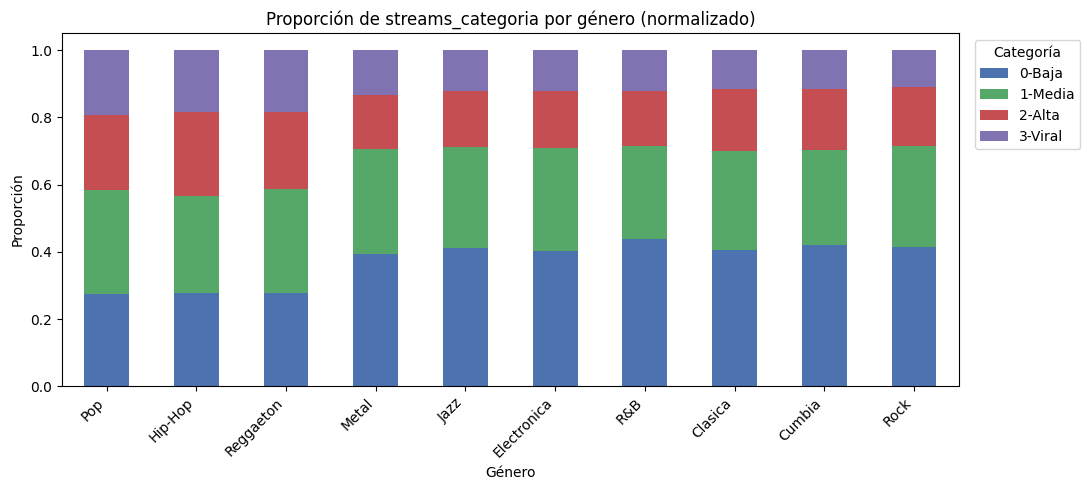

In [26]:
tabla.plot(kind="bar", stacked=True, figsize=(11, 5),
           color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Proporción de streams_categoria por género (normalizado)")
plt.xlabel("Género")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Categoría", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## Ejercicio 2 — Análisis con NumPy 🔢

En este ejercicio trabajarás directamente con **arrays de NumPy** extraídos del dataset. Los métodos usados son exactamente los del apunte de clases.

### 2.1 — Crear arrays desde el DataFrame

Extrae las columnas `energia`, `bailabilidad`, `popularidad_artista` y `streams_categoria` como arrays de NumPy usando `.to_numpy()`.

Imprime el tipo (`dtype`) y la forma (`shape`) de cada array.

In [21]:
energia      = df["energia"].to_numpy()
bailabilidad = df["bailabilidad"].to_numpy()
popularidad  = df["popularidad_artista"].to_numpy()
streams      = df["streams_categoria"].to_numpy()

for nombre, arr in [("energia", energia), ("bailabilidad", bailabilidad),
                    ("popularidad", popularidad), ("streams", streams)]:
    print(f"{nombre:15s} — shape: {arr.shape}, dtype: {arr.dtype}")

energia         — shape: (15000,), dtype: float64
bailabilidad    — shape: (15000,), dtype: float64
popularidad     — shape: (15000,), dtype: int64
streams         — shape: (15000,), dtype: int64


### 2.2 — Estadísticas básicas

Usando las funciones de NumPy vistas en los contenidos (`np.mean`, `np.median`, `np.std`, `np.min`, `np.max`), calcula estas estadísticas para el array `popularidad_artista`.

> ¿Cuánto es la desviación estándar? ¿Qué nos dice eso sobre los datos?

In [22]:
print(f"Media:              {np.mean(popularidad):.2f}")
print(f"Mediana:            {np.median(popularidad):.2f}")
print(f"Desviación std:     {np.std(popularidad):.2f}")
print(f"Varianza:           {np.var(popularidad):.2f}")
print(f"Mínimo:             {np.min(popularidad)}")
print(f"Máximo:             {np.max(popularidad)}")
print(f"Índice del máximo:  {np.argmax(popularidad)}")

Media:              50.03
Mediana:            50.00
Desviación std:     29.22
Varianza:           854.04
Mínimo:             0
Máximo:             100
Índice del máximo:  37


La desviación estándar de ~29 sobre una escala de 0-100 indica que los valores están bastante dispersos: hay artistas muy poco conocidos y artistas extremadamente populares conviviendo en el dataset. La media y la mediana son similares (~50), lo que indica una distribución aproximadamente simétrica.

### 2.3 — Operaciones aritméticas y con escalares

Crea un nuevo array `energia_pct` que represente la energía como porcentaje (multiplicando por 100). Luego crea `tempo_normalizado` que lleve el array `tempo_bpm` al rango [0, 1] restando el mínimo y dividiendo por el rango.

Imprime los primeros 10 valores de cada uno.

In [23]:
tempo = df["tempo_bpm"].to_numpy()

energia_pct = energia * 100
tempo_normalizado = (tempo - np.min(tempo)) / (np.max(tempo) - np.min(tempo))

print("energia_pct (primeros 10):      ", energia_pct[:10])
print("tempo_normalizado (primeros 10):", tempo_normalizado[:10].round(3))

energia_pct (primeros 10):       [47.7 33.6 55.8 61.  80.9 31.7 61.3 53.1 94.  63.8]
tempo_normalizado (primeros 10): [0.519 0.639 0.707 0.541 0.624 0.301 0.556 0.346 0.609 0.496]


Multiplicar por un escalar (`* 100`) se aplica a cada elemento del array sin usar ningún loop. Lo mismo ocurre con la normalización: las operaciones `- np.min(tempo)` y `/ (rango)` se aplican a todos los elementos simultáneamente gracias al broadcasting.

### 2.4 — Operaciones lógicas y comparaciones

Usando comparaciones y operaciones lógicas sobre arrays:
- ¿Cuántas canciones tienen `energia > 0.8`?
- ¿Cuántas tienen `energia > 0.8` **y** `bailabilidad > 0.8` al mismo tiempo?
- ¿Cuántas canciones virales (`streams == 3`) tienen `popularidad_artista < 30`?

In [24]:
alta_energia = energia > 0.8
alta_baila   = bailabilidad > 0.8

print(f"Canciones con energia > 0.8:                       {np.sum(alta_energia)}")
print(f"Canciones con energia > 0.8 Y bailabilidad > 0.8:  {np.sum(alta_energia & alta_baila)}")
print(f"Canciones virales con popularidad < 30:            {np.sum((streams == 3) & (popularidad < 30))}")

Canciones con energia > 0.8:                       2699
Canciones con energia > 0.8 Y bailabilidad > 0.8:  492
Canciones virales con popularidad < 30:            249


Las comparaciones sobre arrays devuelven arrays booleanos (`True`/`False`). Al aplicar `np.sum()` sobre un array booleano, Python cuenta los `True` como 1 y los `False` como 0, entregando el total de elementos que cumplen la condición. El operador `&` combina condiciones elemento a elemento.

---
## ✅ ¡Misión completada!

Lograste analizar un dataset musical real usando las herramientas del curso:

- **Pandas**: carga de CSV, `.info()`, `.describe()`, `.head()`, filtrado, `.groupby()`, nuevas columnas, `pd.crosstab()` y visualización
- **NumPy**: arrays desde DataFrames, estadísticas básicas, operaciones con escalares, comparaciones lógicas y análisis por grupo con indexación booleana

El siguiente paso en tu camino al DCCHine Learning será usar estos datos limpios para entrenar tu primer modelo predictivo, pero eso sera problema para algun otro ramo. 🚀

MUCHAS GRACIAS POR SU ASISTIR A LA ULTIMA AYUDANTÍA DE ESTE CURSO. ESPERAMOS QUE HAYAN APRENDIDO MUCHO Y QUE ESTÉN LISTOS PARA EL PRÓXIMO NIVEL. ¡ÉXITO EN SUS PROYECTOS FUTUROS! ❤️